<a href="https://colab.research.google.com/github/jatin-reddy/Semantic_Similarity_NLP/blob/main/Semantic_Similarity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Semantic Similarity
Build a prediction system to find whether two sentences are semantically similar.

Dataset: https://www.kaggle.com/datasets/quora/question-pairs-dataset

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("quora/question-pairs-dataset")

print("Path to dataset files:", path)

100%|██████████| 20.8M/20.8M [00:00<00:00, 74.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/quora/question-pairs-dataset/versions/2


In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


df_path = "/root/.cache/kagglehub/datasets/quora/question-pairs-dataset/versions/2"
df_path = os.path.join(df_path, "questions.csv")
df = pd.read_csv(df_path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404351 entries, 0 to 404350
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            404351 non-null  int64 
 1   qid1          404351 non-null  int64 
 2   qid2          404351 non-null  int64 
 3   question1     404350 non-null  object
 4   question2     404349 non-null  object
 5   is_duplicate  404351 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 18.5+ MB


##Basic Data Preprocessing
We are not using general text-preprocessing methods like tokenisation, stopword removal etc because we have to feed raw-data to our embeddings model (Bi-Encoder MiniLM-L6-v2) to get the most accurate embeddings.

In [4]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [5]:
print(df.isnull().sum())
df = df.dropna()

id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64


In [6]:
print(df.isnull().sum())

id              0
qid1            0
qid2            0
question1       0
question2       0
is_duplicate    0
dtype: int64


In [7]:
print(df['is_duplicate'].value_counts())
print(df['is_duplicate'].value_counts(normalize=True))

is_duplicate
0    255042
1    149306
Name: count, dtype: int64
is_duplicate
0    0.630749
1    0.369251
Name: proportion, dtype: float64


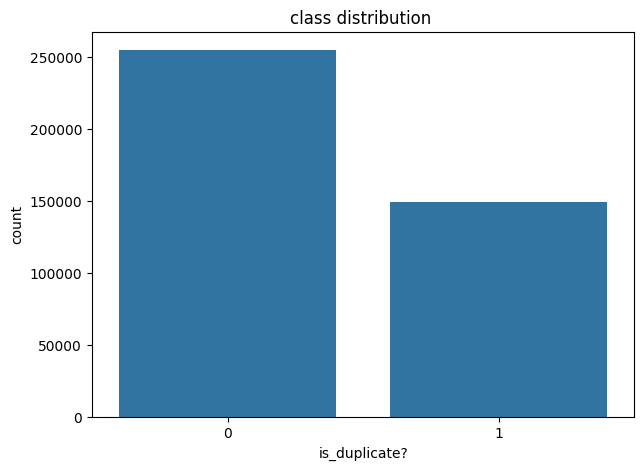

In [7]:
# 0 = not similar, 1 = similar
plt.figure(figsize=(7, 5))
sns.countplot(x='is_duplicate', data=df)
plt.title('class distribution ')
plt.xlabel('is_duplicate?')
plt.ylabel('count')
plt.show()

In [9]:
# We'll use a small random sample to work with
sample_size = 20000
df_sample = df.sample(n=sample_size, random_state=42)
df_sample.head()

,id,qid1,qid2,question1,question2,is_duplicate
371032,371032,726051,726052,Do people realize that you can send marijuana ...,How do you send weed through the mail?,0
263498,263498,518455,518456,How can rock music be brought back?,What would it take for rock music to make a co...,1
111008,111008,220125,220126,Why does one feel relaxed after smoking a join...,How do I sober up quickly after smoking weed/m...,0
75665,75665,150351,150352,How to gain weight ?,How do I gain weight fast but still be healthy?,1
52376,52376,104229,104230,Is porn bad for men?,Can I become a porn fan without getting addicted?,0


In [9]:
!pip install -U sentence-transformers

###Generate embeddings for the dataset

In [11]:
# Embeddings using Sentence-BERT (bi-encoders: sentence-transformers/all-MiniLM-L6-v2)
# https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2

from sentence_transformers import SentenceTransformer
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

unique_questions_set = set(df_sample['question1']) | set(df_sample['question2'])
unique_questions_list = list(unique_questions_set)


print(f"sample question pairs = {len(df_sample)}") #20000
print(f"sample unique questions = {len(unique_questions_list)}")

unique_questions_embeddings = model.encode(unique_questions_list)
print(f"unique questions embeddings shape = {unique_questions_embeddings.shape}")

sample question pairs = 20000
sample unique questions = 37770
unique questions embeddings shape = (37770, 384)


In [11]:
embedding_map = {question: embedding for question, embedding in zip(unique_questions_list, unique_questions_embeddings)}


df_sample['embedding1'] = df_sample['question1'].map(embedding_map)
df_sample['embedding2'] = df_sample['question2'].map(embedding_map)

In [12]:
print(df_sample.head())

            id    qid1    qid2  \
371032  371032  726051  726052   
263498  263498  518455  518456   
111008  111008  220125  220126   
75665    75665  150351  150352   
52376    52376  104229  104230   

                                                question1  \
371032  Do people realize that you can send marijuana ...   
263498                How can rock music be brought back?   
111008  Why does one feel relaxed after smoking a join...   
75665                                How to gain weight ?   
52376                                Is porn bad for men?   

                                                question2  is_duplicate  \
371032             How do you send weed through the mail?             0   
263498  What would it take for rock music to make a co...             1   
111008  How do I sober up quickly after smoking weed/m...             0   
75665     How do I gain weight fast but still be healthy?             1   
52376   Can I become a porn fan without getting addic

### Given two sentences compute how similar they are (pick the best similarity metric)
***Best Similarity Metric: Cosine Similarity***

Cosine similarity focuses on the angle between vectors rather than their magnitude, so it captures how directionally similar two meanings are instead of how long the vectors are.


In [13]:
# Cosine Similarity (cos theta = a.b/||a||b||) - needs 2D arrays, but embeddings are list (384,)
from sklearn.metrics.pairwise import cosine_similarity

def calculate_similarity(row):
    a = row['embedding1'].reshape(1, -1)
    b = row['embedding2'].reshape(1, -1)
    return cosine_similarity(a, b)[0][0]

df_sample['similarity_score'] = df_sample.apply(calculate_similarity, axis=1)

In [14]:
df_sample.head()

,id,qid1,qid2,question1,question2,is_duplicate,embedding1,embedding2,similarity_score
371032,371032,726051,726052,Do people realize that you can send marijuana ...,How do you send weed through the mail?,0,"[0.113820225, 0.05862062, -0.02589315, 0.06607...","[0.05745311, 0.03617924, -0.029303692, 0.02588...",0.530007
263498,263498,518455,518456,How can rock music be brought back?,What would it take for rock music to make a co...,1,"[0.026633058, -0.01365615, 0.08153441, -0.0093...","[-0.0098707825, -0.04576926, 0.0774877, -0.009...",0.890434
111008,111008,220125,220126,Why does one feel relaxed after smoking a join...,How do I sober up quickly after smoking weed/m...,0,"[0.09647977, -0.0243971, -0.009551516, 0.08785...","[0.07329396, -0.00772813, -0.0148641225, 0.073...",0.511294
75665,75665,150351,150352,How to gain weight ?,How do I gain weight fast but still be healthy?,1,"[-0.04800163, 0.044627417, -0.047336098, 0.117...","[-0.0038795928, 0.053808674, -0.054131042, 0.0...",0.789358
52376,52376,104229,104230,Is porn bad for men?,Can I become a porn fan without getting addicted?,0,"[0.06376452, -0.007898415, 0.015402348, 0.0017...","[0.07194531, -0.14561903, -0.015645945, 0.0231...",0.493581


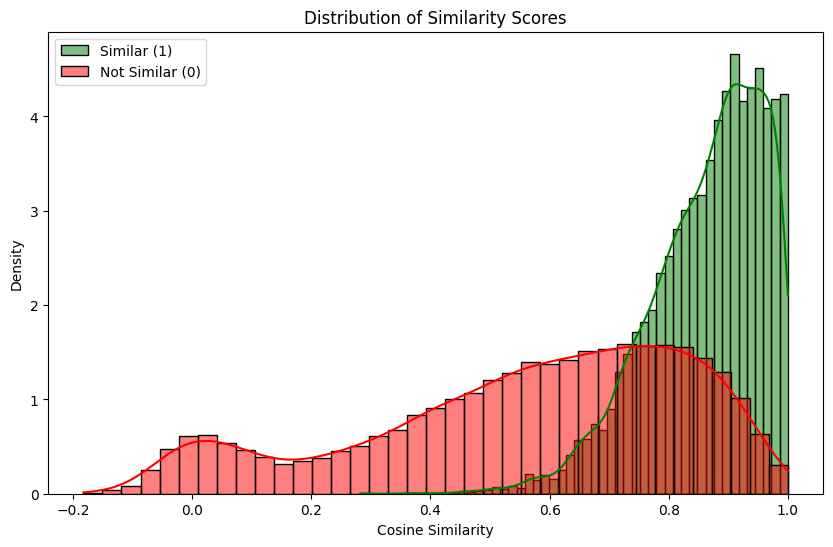

In [15]:
# let's plot density 0/1 is_duplicate and similarity score for each question
plt.figure(figsize=(10, 6))
sns.histplot(df_sample[df_sample['is_duplicate'] == 1]['similarity_score'],
             color='green', label='Similar (1)', kde=True, stat='density')
sns.histplot(df_sample[df_sample['is_duplicate'] == 0]['similarity_score'],
             color='red', label='Not Similar (0)', kde=True, stat='density')
plt.legend()
plt.title('Distribution of Similarity Scores')
plt.xlabel('Cosine Similarity')
plt.show()

###Build a K-Means clustering algorithm from scratch and cluster the data to find similar groups of questions

In [16]:
import numpy as np

# K Means from scratch

# 1. pick k initial centers (let's pick k random datapoints)
# 2. every datapoint is clustered with the one center with least distance -> Clustering function
# 3. Recenter each cluster's center by taking the average coordinate of the cluster
# 4. Repeat step 2 and 3 until centers of clusters stop moving (or max_iterations)

class k_means():
  def __init__(self, k=5, max_iterations=100):
    self.k = k
    self.max_iterations = max_iterations
    self.centers = None # List of cluster centers
    self.labels = None

  def calc_distance(self, p1, p2):
    return np.sum((p1-p2)**2)

  def clustering(self, X):
    # X.shape = n_samples, n_features
    n_samples = X.shape[0]
    labels = np.zeros(n_samples, dtype = int)
    for i in range(n_samples):
      distances = [self.calc_distance(X[i], center) for center in self.centers]
      closest_center = np.argmin(distances)
      labels[i] = closest_center
    return labels

  def update_cluster_centers(self, X):
    n_features = X.shape[1]
    new_centers = np.zeros((self.k, n_features))
    for i in range(self.k):
      points_in_cluster = X[self.labels==i]

      if len(points_in_cluster) > 0:
        new_centers[i] = np.mean(points_in_cluster, axis=0)
      else:
        new_centers[i] = X[np.random.choice(X.shape[0])]
    return new_centers

  def fit(self, X):
    n_samples, n_features = X.shape

    random_indices = np.random.choice(n_samples, self.k, replace=False)
    self.centers = X[random_indices]

    for i in range(self.max_iterations):

      self.labels = self.clustering(X)
      current_centers = self.centers.copy()
      self.centers= self.update_cluster_centers(X)

      centers_shift = np.sum((self.centers - current_centers)**2)
      if centers_shift < 1e-4:
        print(f"Converged and cluster centers stopped moving at {i+1} iterations")
        break
      elif i == self.max_iterations - 1:
        print(f"K-means did not converge after {self.max_iterations} iterations")

    print("K-means clustering complete")

In [17]:
X = unique_questions_embeddings
k_val = 8
print(f"K-Means | k={k_val}...")

kMeans = k_means(k=k_val, max_iterations=100)
kMeans.fit(X)
cluster_labels = kMeans.labels

print(f"data shape: {X.shape}")
print(f"labels shape: {cluster_labels.shape}")
print(f"first 10 labels: {cluster_labels[:10]}")

K-Means | k=8...
Converged and cluster centers stopped moving at 28 iterations
K-means clustering complete
data shape: (37770, 384)
labels shape: (37770,)
first 10 labels: [0 4 0 1 7 4 1 5 1 3]


###Visualize clusters using PCA.


In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"original mean: {X[:, 0].mean():.4f}")
print(f"scaled mean: {X_scaled[:, 0].mean():.4f}")

original mean: -0.0026
scaled mean: 0.0000


In [19]:
print("Performing PCA on the question embeddings")
labels = cluster_labels
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

Performing PCA on the question embeddings


In [20]:
print("Explained variance:", pca.explained_variance_ratio_)
print("Cumulative:", np.cumsum(pca.explained_variance_ratio_))

Explained variance: [0.02632434 0.02314966]
Cumulative: [0.02632434 0.049474  ]


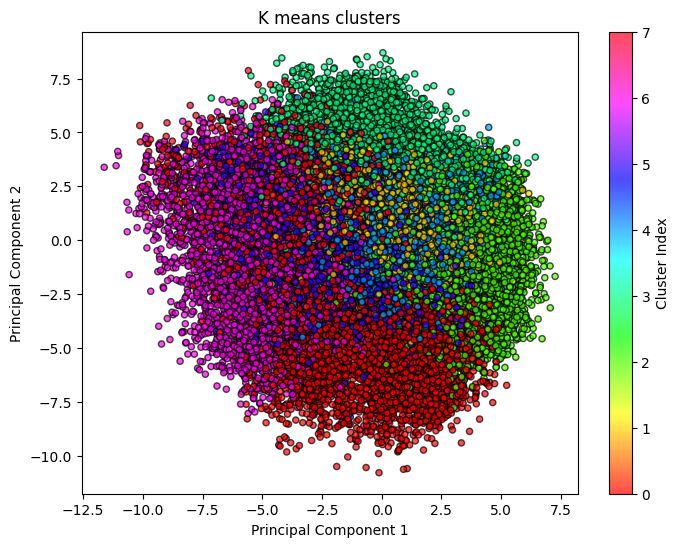

In [21]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='hsv', edgecolor='k', alpha=0.7, s=20)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K means clusters")
plt.colorbar(label="Cluster Index")
plt.show()

Running kmeans from k=2 to k=15 to calculate WCSS
Converged and cluster centers stopped moving at 57 iterations
K-means clustering complete
k=2 - inertia: 33353.31770965477
Converged and cluster centers stopped moving at 11 iterations
K-means clustering complete
k=3 - inertia: 33378.92377274957
Converged and cluster centers stopped moving at 21 iterations
K-means clustering complete
k=4 - inertia: 33429.529430092596
Converged and cluster centers stopped moving at 25 iterations
K-means clustering complete
k=5 - inertia: 33373.17320010283
Converged and cluster centers stopped moving at 21 iterations
K-means clustering complete
k=6 - inertia: 33352.6960748953
Converged and cluster centers stopped moving at 31 iterations
K-means clustering complete
k=7 - inertia: 33372.86023261909
Converged and cluster centers stopped moving at 15 iterations
K-means clustering complete
k=8 - inertia: 33403.26219044248
Converged and cluster centers stopped moving at 18 iterations
K-means clustering complete

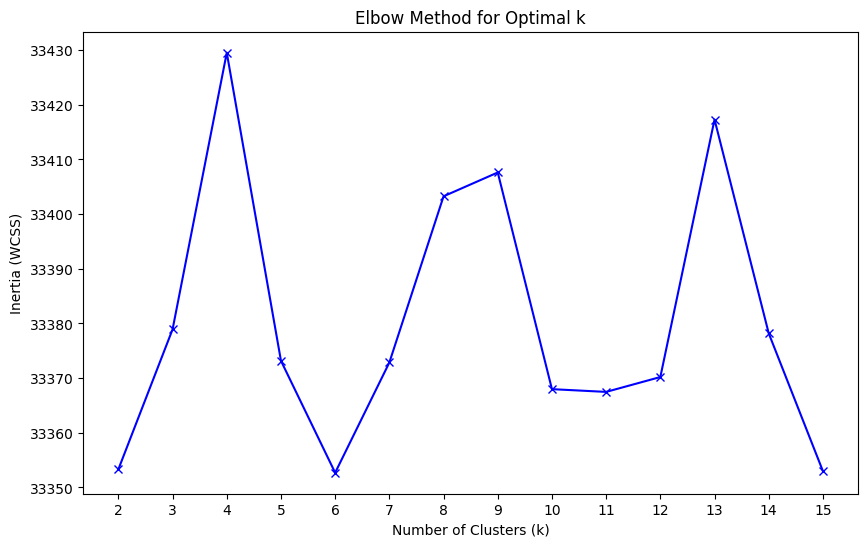

In [22]:
# Experimenting with different n_cluster values (Elbow method)
def calculate_inertia(kmeans_model, X):
    total_inertia = 0
    n_samples = X.shape[0]

    for i in range(n_samples):
        label = kMeans.labels[i]
        center = kMeans.centers[label]
        total_inertia += np.sum((X[i] - center)**2)
    return total_inertia

k_range = range(2, 16)
inertia_values = []

print("Running kmeans from k=2 to k=15 to calculate WCSS")

for k in k_range:
    kMeans = k_means(k=k_val, max_iterations=100)
    kMeans.fit(X)

    if kMeans.labels is not None:
        inertia = calculate_inertia(kMeans, X)
        inertia_values.append(inertia)
        print(f"k={k} - inertia: {inertia}")
    else:
        print(f"k={k} - error.")
        inertia_values.append(np.nan)


plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia_values, 'bx-')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.xticks(k_range)
plt.show()



In [23]:
# current k = 15
cluster_df = pd.DataFrame({
    'Question': unique_questions_list,
    'Cluster_No.': cluster_labels
})


print("Cluster sizes :")
cluster_counts = cluster_df['Cluster_No.'].value_counts()
largest_cluster = cluster_counts.index[0]
print(cluster_counts)
print("\n")

SAMPLE_SIZE = 15
print(f"Sample questions from the largest cluster")

questions_in_cluster = cluster_df[cluster_df['Cluster_No.'] == largest_cluster]['Question'].sample(SAMPLE_SIZE, random_state=42)
questions_in_cluster

Cluster sizes :
Cluster_No.
4    6374
1    6062
2    5204
3    4731
5    4041
6    3936
7    3838
0    3584
Name: count, dtype: int64


Sample questions from the largest cluster


,Question
11732,Why is it important to rinse with salt water a...
26304,Can I get arrested for downloading movies from...
30472,Why doesn't Skype exit when we close the windo...
25116,Should I get the Plume or Armor fossil in Poké...
34958,How can I get my instagram back without using ...
1554,Will a core i5 65xx bottleneck a GTX 1070 when...
15680,How do I send a book post?
2005,My Twitter account has been hacked and I want ...
29102,Who is behind The Honest Page on Facebook?
17590,Why do I wake up with swollen hands?


In [24]:
smallest_cluster = cluster_counts.index[-1]
smallest_cluster_size = cluster_counts.iloc[-1]

SAMPLE_SIZE = min(15, smallest_cluster_size)
print(f"Sample questions from the smallest cluster")

questions_in_cluster = cluster_df[cluster_df['Cluster_No.'] == smallest_cluster]['Question'].sample(SAMPLE_SIZE, random_state=42)
questions_in_cluster

Sample questions from the smallest cluster


,Question
25637,How do I improve my German speaking skills?
24386,How do I get over a girl I like?
9498,What are some lucid dreaming tips?
1891,There are few people who can read your mind.Ho...
29797,How do you accept your life?
1159,How do I stop feeling inferior and sad about m...
24490,How can I overcome my depression and my fears?
260,What are the most effective ways to improve se...
12613,How would you help a shy person to become a co...
24363,How do I want to live my life again?


Smallest cluster seems to have some semantic similarity (self-improvement aah in this sample xD)

### Experiment with other clustering algorithms and compare results.

Total data points: 37770
original mean: -0.0026
scaled mean: 0.0000

Agglomerative Clustering...

Performing PCA on the question embeddings sample...


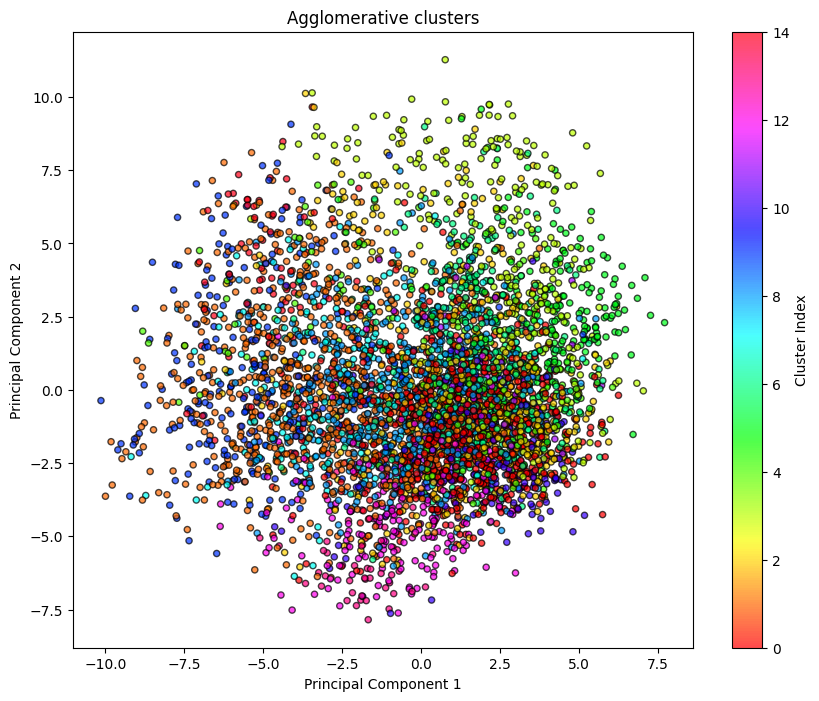

Total variance retained by PC1 and PC2: 0.05


In [12]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = unique_questions_embeddings
sample_size = 5000
n_clusters = 15

np.random.seed(42)
sample_indices = np.random.choice(X.shape[0], sample_size, replace=False)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_sample_scaled = X_scaled[sample_indices]

print(f"Total data points: {X.shape[0]}")
print(f"original mean: {X[:, 0].mean():.4f}")
print(f"scaled mean: {X_scaled[:, 0].mean():.4f}")

print("\nAgglomerative Clustering...")
agglo_model = AgglomerativeClustering(n_clusters=n_clusters)
agglo_labels = agglo_model.fit_predict(X_sample_scaled)

print("\nPerforming PCA on the question embeddings sample...")
labels = agglo_labels
pca = PCA(n_components=2)
X_pca_sample = pca.fit_transform(X_sample_scaled)

plt.figure(figsize=(10, 8))
plt.scatter(
    X_pca_sample[:, 0],
    X_pca_sample[:, 1],
    c=labels,
    cmap='hsv',
    edgecolor='k',
    alpha=0.7,
    s=20
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Agglomerative clusters")
plt.colorbar(label="Cluster Index")
plt.show()

print(f"Total variance retained by PC1 and PC2: {pca.explained_variance_ratio_.sum():.2f}")

In [15]:
sampled_questions_list = [unique_questions_list[i] for i in sample_indices]

cluster_agglo_df = pd.DataFrame({
    'Question': sampled_questions_list,
    'Cluster_ID': agglo_labels
})

print("Agglomerative cluster sizes:")
cluster_counts_agglo = cluster_agglo_df['Cluster_ID'].value_counts()

smallest_cluster_agglo_id = cluster_counts_agglo.index[-1]
smallest_cluster_agglo_size = cluster_counts_agglo.iloc[-1]

SAMPLE_SIZE = min(15, smallest_cluster_agglo_size)

print(f"Cluster ID: #{smallest_cluster_agglo_id} | Total Size: {smallest_cluster_agglo_size} questions")

questions_in_cluster = cluster_agglo_df[cluster_agglo_df['Cluster_ID'] == smallest_cluster_agglo_id]['Question'].sample(SAMPLE_SIZE, random_state=42)
questions_in_cluster

Agglomerative cluster sizes:
Cluster ID: #13 | Total Size: 44 questions


,Question
4256,Can I send 500 and 1000 rs cash notes to India...
3074,What is the rationale behind introducing 2000 ...
3145,Why does RBI / Government of India not opt for...
4155,What will be the pros and cons of the replacem...
3986,What are your views on India banning 500 and 1...
4704,Why did the Indian government develop a 1000 r...
720,"So how does banning 500, 1000 rs and introduci..."
1374,What is the main reason for discontinuing 500 ...
1013,How will the decision to illegalize the 500 an...
593,What do you think of the decision by the India...


Damn! Agglomerative Cluster is so much better at it